In [25]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [26]:
# Load both datasets
game_stats = pd.read_csv('../Cleaned Data/Finished/PlayerStatistics.csv', low_memory=False)
injuries = pd.read_csv('../Cleaned Data/Finished/injury_locations_categorized.csv')

# only 2010-2020
game_stats['gameDate'] = pd.to_datetime(game_stats['gameDate'], errors='coerce')
game_stats = game_stats[
    (game_stats['gameDate'].dt.year >= 2010) &
    (game_stats['gameDate'].dt.year <= 2020)
]

In [27]:
# Summarize per player
player_summary = game_stats.groupby('personId').agg({
    'firstName': 'first',
    'lastName': 'first',
    'numMinutes': ['count', 'mean'],
    'points': 'mean',
    'assists': 'mean',
    'reboundsTotal': 'mean'
}).reset_index()

# Rename columns
player_summary.columns = [
    'personId', 'firstName', 'lastName',
    'games_played', 'avg_minutes',
    'avg_points', 'avg_assists', 'avg_rebounds'
]

# Avoid 1-20 game players
player_summary = player_summary[player_summary['games_played'] >= 20]


In [28]:
# Summarize injuries per player
injury_summary = injuries.groupby('Relinquished').size().reset_index(name='injury_count')

# Merge injury data
player_summary['full_name'] = player_summary['firstName'] + ' ' + player_summary['lastName']
merged = pd.merge(player_summary, injury_summary, how='left', left_on='full_name', right_on='Relinquished')

# Fill missing injuries with 0
merged['injury_count'] = merged['injury_count'].fillna(0)
merged.head()

,personId,firstName,lastName,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,full_name,Relinquished,injury_count
0,255,Grant,Hill,234,26.564103,8.838828,1.835165,3.472527,Grant Hill,Grant Hill,16.0
1,406,Shaquille,O'Neal,80,20.637500,8.968750,0.895833,4.375000,Shaquille O'Neal,Shaquille O'Neal,13.0
2,436,Juwan,Howard,171,13.046784,2.341085,0.341085,1.794574,Juwan Howard,Juwan Howard,1.0
3,467,Jason,Kidd,307,30.309446,7.276190,6.034921,4.400000,Jason Kidd,Jason Kidd,8.0
4,686,Antonio,McDyess,141,19.936170,5.250000,1.098684,5.302632,Antonio McDyess,Antonio McDyess,1.0


In [29]:
features = merged[['games_played', 'avg_minutes', 'avg_points', 'avg_assists', 'avg_rebounds', 'injury_count']]

# Drop NaN players
features = features.dropna()

# Match merged rows to features
merged = merged.loc[features.index].reset_index(drop=True)

In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

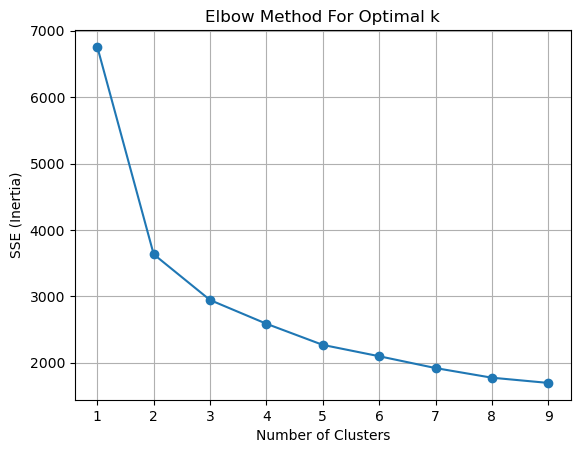

In [31]:
sse = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    sse.append(kmeans.inertia_)

# Plot
plt.plot(range(1, 10), sse, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [32]:
# Choose 4 clusters based on elbow
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Assign cluster labels
merged['injury_risk_cluster'] = clusters


In [33]:
# Analyze clusters
cluster_summary = merged.groupby('injury_risk_cluster').mean(numeric_only=True)
display(cluster_summary)

,personId,games_played,avg_minutes,avg_points,avg_assists,avg_rebounds,injury_count
injury_risk_cluster,,,,,,,
0,607795.951613,342.973118,21.347030,7.362136,1.496687,3.270150,6.430108
1,706413.907579,103.170055,11.691675,2.687234,0.578927,1.399656,1.933457
2,130389.813725,571.303922,24.850333,9.189281,2.115393,3.779930,32.568627
3,470072.828829,575.567568,30.365844,15.512561,3.696002,5.563334,12.288288


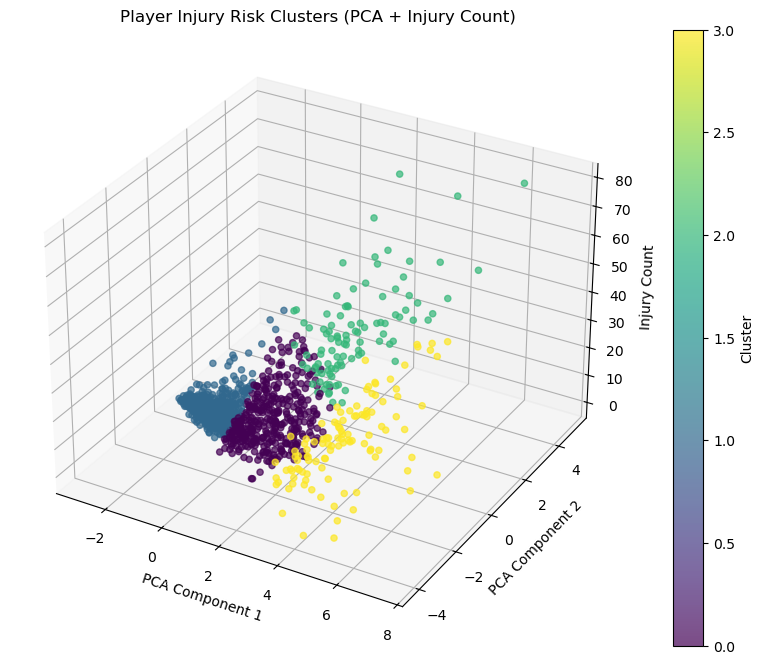

In [35]:
from mpl_toolkits.mplot3d import Axes3D  # 3D plotting

# Reduce features to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Prepare 3D Data
injury_counts = merged['injury_count'].values  # Z-axis
avg_minutes = merged['avg_minutes'].values     # Dot size

# Normalize dot size (optional to keep it looking good)
size_scaled = (avg_minutes - avg_minutes.min()) / (avg_minutes.max() - avg_minutes.min())
size_scaled = 50 + (size_scaled * 150)  # Scale from 50 to 200

# Plot
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],        # X = PCA Component 1
    X_pca[:, 1],        # Y = PCA Component 2
    injury_counts,      # Z = Injury Count
    c=clusters,         # Color by cluster
    s=size_scaled,      # Dot size = avg minutes
    cmap='viridis',
    alpha=0.7,
    edgecolors='w'
)

ax.set_xlabel('PCA Component 1')
ax.set_ylabel('PCA Component 2')
ax.set_zlabel('Injury Count')
ax.set_title('Player Injury Risk Clusters (PCA + Injury Count + Avg Minutes Size)')

fig.colorbar(scatter, ax=ax, label='Cluster')
plt.show()
